<a href="https://colab.research.google.com/github/EgiNHardo/EgiNHardo-Proyecto1/blob/main/PRISMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Cargar archivo en Colab

In [4]:
from google.colab import files
import pandas as pd

# Subir archivo exportado desde Scopus (en formato .csv)
uploaded = files.upload()

# Cargar el archivo (asume que es el primero cargado)
filename = next(iter(uploaded))
df = pd.read_csv(filename, encoding='utf-8')

# Mostrar primeras filas para revisar
df.head()


Saving SCOPUS.csv to SCOPUS.csv


,Authors,Author full names,Author(s) ID,Title,Year,Source title,Volume,Issue,Art. No.,Page start,...,ISSN,ISBN,CODEN,PubMed ID,Language of Original Document,Document Type,Publication Stage,Open Access,Source,EID
0,"Xu, X.-Y.; Wu, G.-C.; Xie, D.","Xu, Xinyi (60114164700); Wu, G. (23390775700);...",60114164700; 23390775700; 57209307348,A new discrete fractional AMAR model for finan...,2025,"Chaos, Solitons and Fractals",201,NaN,117296,NaN,...,09600779,NaN,CSFOE,NaN,English,Article,Final,NaN,Scopus,2-s2.0-105017003082
1,"Bogensperger, L.; Ehrhardt, M.J.; Pock, T.; Sa...","Bogensperger, Lea (57542223400); Ehrhardt, Mat...",57542223400; 55248138800; 6506341512; 57472957...,An Adaptively Inexact Method for Bilevel Learn...,2025,Journal of Mathematical Imaging and Vision,67,5,49,NaN,...,15737683; 09249907,NaN,JMIVE,NaN,English,Article,Final,All Open Access; Hybrid Gold Open Access,Scopus,2-s2.0-105013844632
2,"Vellappandi, M.; Lee, S.","Vellappandi, Madasamy (57226550675); Lee, S. M...",57226550675; 59510733500,Physics-informed neural fractional differentia...,2025,Applied Mathematical Modelling,145,NaN,116127,NaN,...,0307904X,NaN,AMMOD,NaN,English,Article,Final,NaN,Scopus,2-s2.0-105002640007
3,"Narayanan, G.; Lee, S.; Ahn, S.","Narayanan, Govindasamy (59089591800); Lee, San...",59089591800; 59812532700; 55468016100,Optimal fractional fuzzy sliding-mode control ...,2025,Journal of the Franklin Institute,362,12,107804,NaN,...,00160032,NaN,JFINA,NaN,English,Article,Final,NaN,Scopus,2-s2.0-105010110910
4,"Wang, X.; Wang, X.; Xu, H.; Qi, H.","Wang, Xin (59312838400); Wang, Xiaoping (57192...",59312838400; 57192626272; 55515434100; 3536711...,Numerical analysis and comparison of fractiona...,2025,Communications in Nonlinear Science and Numeri...,147,NaN,108833,NaN,...,10075704,NaN,NaN,NaN,English,Article,Final,NaN,Scopus,2-s2.0-105002774854


2. Instalar y cargar librerías necesarias

In [5]:
# Instalación de bibliotecas necesarias
!pip install matplotlib seaborn plotly openpyxl

# Carga de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Configuración visual
sns.set(style='whitegrid')


3. Limpieza y selección de datos (PRISMA - selección de estudios)

In [6]:
# Tamaño inicial del dataset
print(f"Registros totales en el archivo original: {df.shape[0]}")

# Eliminación de duplicados por título
df_clean = df.drop_duplicates(subset='Title')
print(f"Registros después de eliminar duplicados por título: {df_clean.shape[0]}")

# (Opcional) Filtrado por tipo de documento si deseas incluir solo artículos científicos
df_clean = df_clean[df_clean['Document Type'] == 'Article']
print(f"Registros después de filtrar solo 'Article': {df_clean.shape[0]}")

# (Opcional) Filtrado por idioma
if 'Language of Original Document' in df_clean.columns:
    df_clean = df_clean[df_clean['Language of Original Document'] == 'English']
    print(f"Registros después de filtrar solo en inglés: {df_clean.shape[0]}")


Registros totales en el archivo original: 110
Registros después de eliminar duplicados por título: 110
Registros después de filtrar solo 'Article': 60
Registros después de filtrar solo en inglés: 60


4. Estadísticas descriptivas

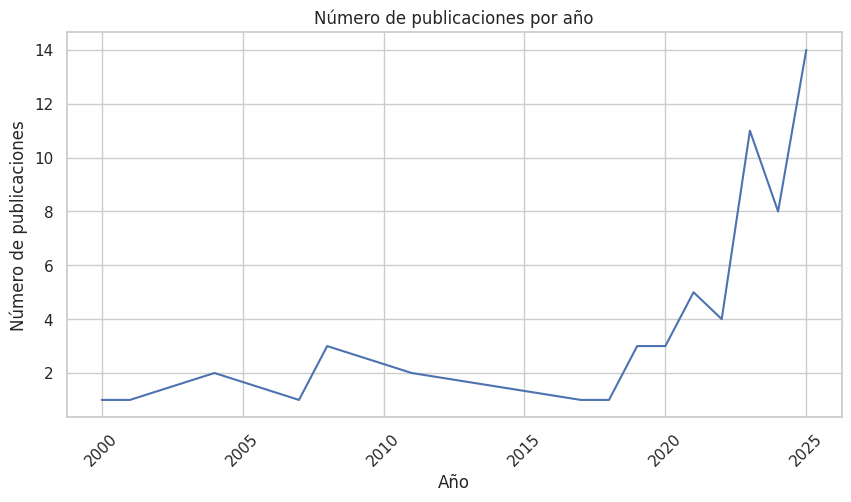

In [7]:
# Años de publicación
df_clean['Year'] = pd.to_numeric(df_clean['Year'], errors='coerce')
publications_per_year = df_clean['Year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.lineplot(x=publications_per_year.index, y=publications_per_year.values)
plt.title('Número de publicaciones por año')
plt.xlabel('Año')
plt.ylabel('Número de publicaciones')
plt.xticks(rotation=45)
plt.show()


/tmp/ipython-input-1575940485.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_sources.index, x=top_sources.values, palette='viridis')


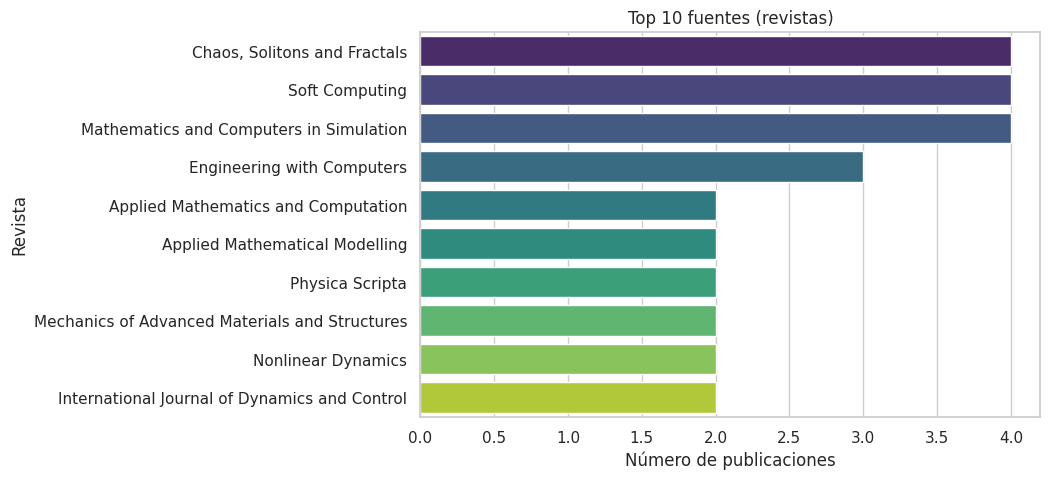

In [8]:
# Revistas más frecuentes
top_sources = df_clean['Source title'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(y=top_sources.index, x=top_sources.values, palette='viridis')
plt.title('Top 10 fuentes (revistas)')
plt.xlabel('Número de publicaciones')
plt.ylabel('Revista')
plt.show()


/tmp/ipython-input-2195292273.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=country_counts.index, x=country_counts.values, palette='magma')


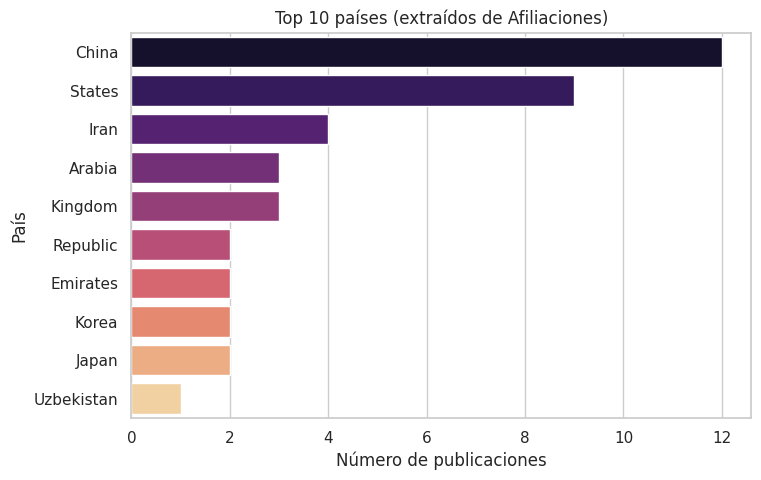

In [9]:
# Países más frecuentes (si existe la columna)
if 'Affiliations' in df_clean.columns:
    country_counts = df_clean['Affiliations'].dropna().str.extractall(r'\b([A-Z][a-z]+)$')[0].value_counts().head(10)
    plt.figure(figsize=(8,5))
    sns.barplot(y=country_counts.index, x=country_counts.values, palette='magma')
    plt.title('Top 10 países (extraídos de Afiliaciones)')
    plt.xlabel('Número de publicaciones')
    plt.ylabel('País')
    plt.show()


5. Exportar archivo limpio (opcional)

In [10]:
# Guardar el dataframe limpio para revisión posterior
df_clean.to_excel("scopus_limpio.xlsx", index=False)
files.download("scopus_limpio.xlsx")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Instalación de librerías adicionales (para análisis de texto y redes)

In [11]:
!pip install networkx wordcloud nltk


Y luego importa:

In [12]:
import networkx as nx
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

A. Red de coautoría (simplificada)

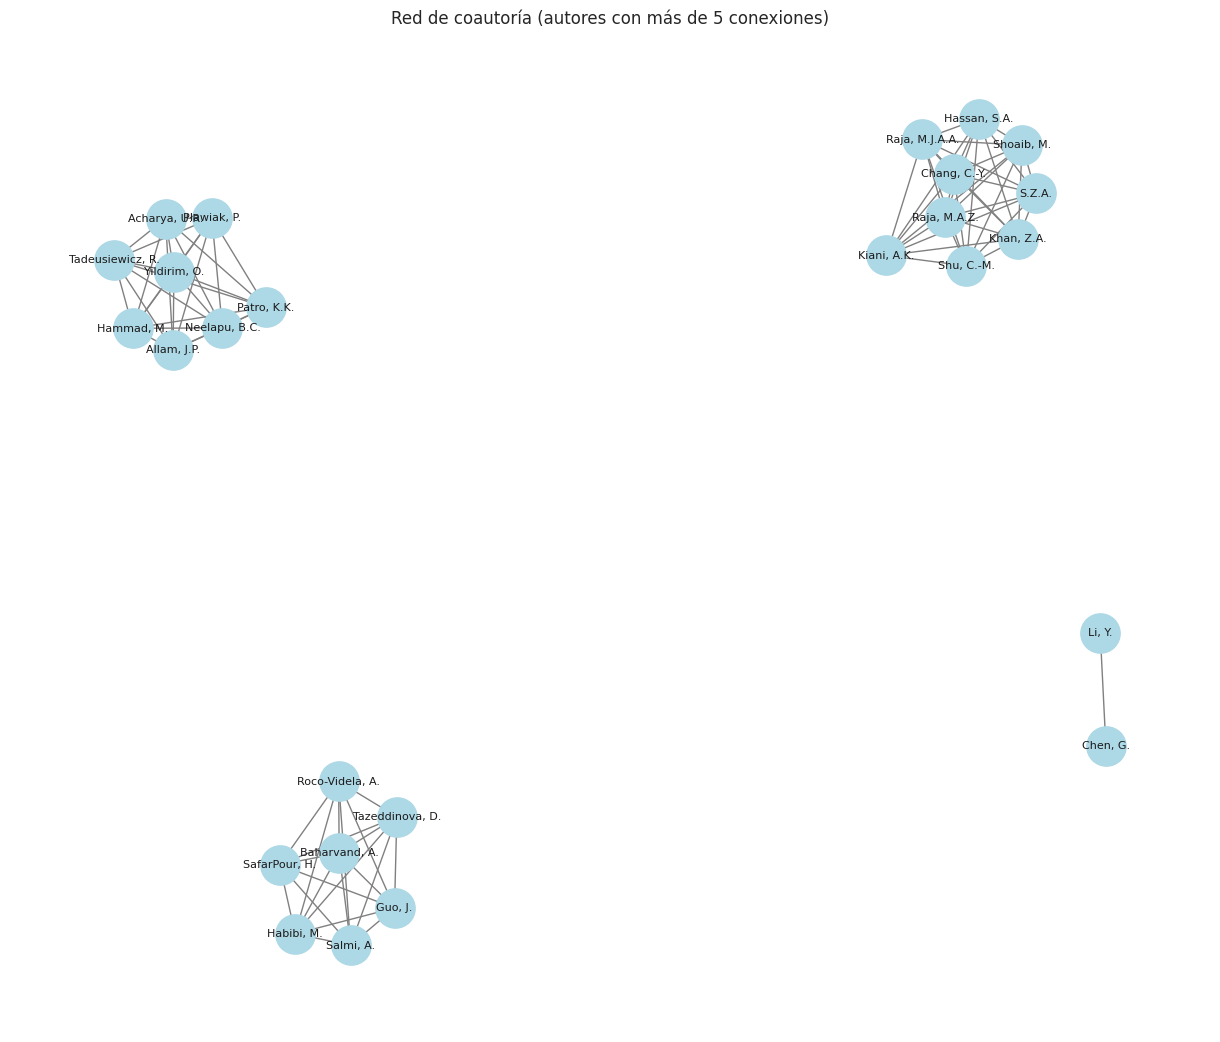

In [13]:
# Separar coautores (Scopus suele usar ';' como separador)
df_clean['Authors'] = df_clean['Authors'].fillna('')
df_clean['Author_List'] = df_clean['Authors'].apply(lambda x: [a.strip() for a in x.split(';') if a.strip()])

# Construcción del grafo
G = nx.Graph()

for authors in df_clean['Author_List']:
    for i in range(len(authors)):
        for j in range(i + 1, len(authors)):
            G.add_edge(authors[i], authors[j])

# Mostrar red (autores con más de N colaboraciones)
top_authors = [node for node, degree in G.degree() if degree > 5]
subgraph = G.subgraph(top_authors)

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(subgraph, k=0.5)
nx.draw(subgraph, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=800, font_size=8)
plt.title("Red de coautoría (autores con más de 5 conexiones)")
plt.show()


B. Nube de palabras (de títulos)

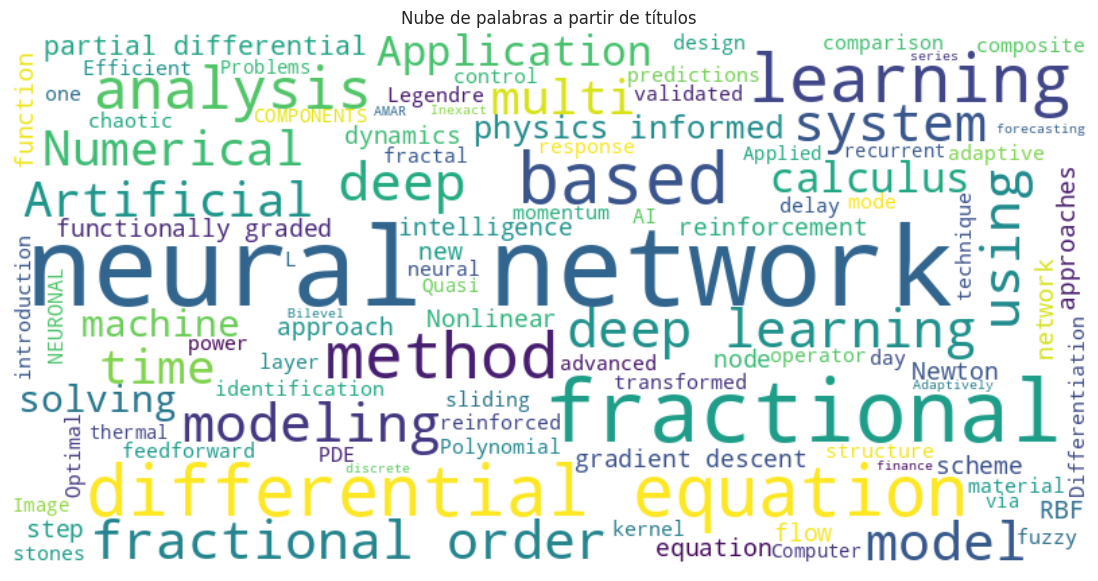

In [14]:
# Crear un texto unificado de todos los títulos
titles_text = ' '.join(df_clean['Title'].dropna().astype(str).tolist())

# Palabras vacías
stop_words = set(stopwords.words('english'))

# Generar la nube
wordcloud = WordCloud(stopwords=stop_words,
                      background_color='white',
                      max_words=100,
                      width=800,
                      height=400).generate(titles_text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Nube de palabras a partir de títulos")
plt.show()


C. Análisis de palabras clave (Author Keywords)

/tmp/ipython-input-652876521.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=keyword_counts.index, x=keyword_counts.values, palette='cubehelix')


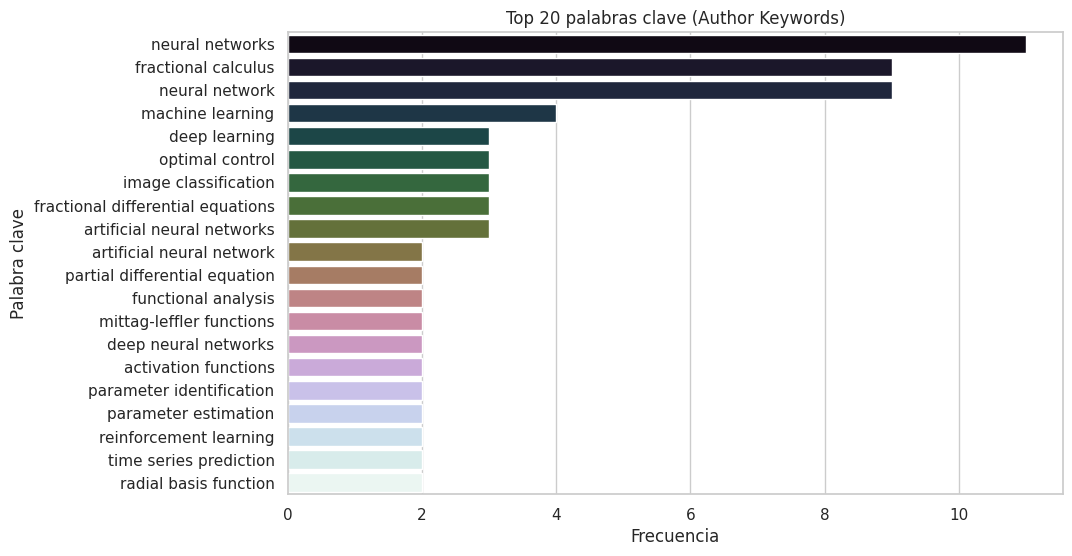

In [15]:
# Asumimos que la columna es 'Author Keywords' o similar
if 'Author Keywords' in df_clean.columns:
    keyword_series = df_clean['Author Keywords'].dropna().str.split(';')
    keywords = keyword_series.explode().str.strip().str.lower()
    keyword_counts = keywords.value_counts().head(20)

    plt.figure(figsize=(10, 6))
    sns.barplot(y=keyword_counts.index, x=keyword_counts.values, palette='cubehelix')
    plt.title("Top 20 palabras clave (Author Keywords)")
    plt.xlabel("Frecuencia")
    plt.ylabel("Palabra clave")
    plt.show()
else:
    print("No se encontró columna 'Author Keywords'.")


D. (Opcional) Matriz de co-ocurrencia de palabras clave (tipo VOSviewer)

/tmp/ipython-input-254669957.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=pair_labels, x=co_df['Count'], palette='coolwarm')


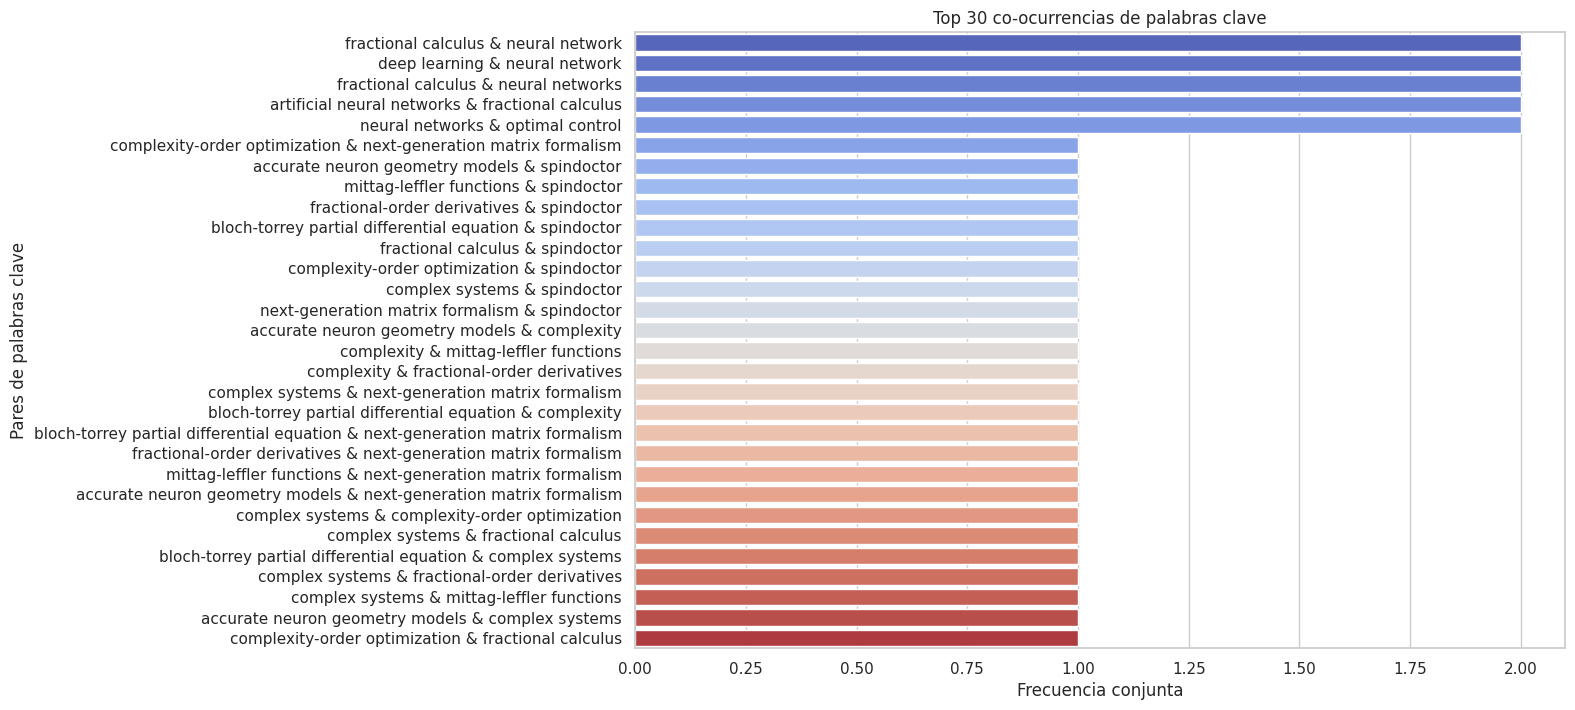

In [16]:
from sklearn.feature_extraction.text import CountVectorizer
from itertools import combinations
from collections import Counter

# Usamos las palabras clave del autor
keyword_lists = df_clean['Author Keywords'].dropna().apply(lambda x: [kw.strip().lower() for kw in x.split(';')])
cooccurrence = Counter()

for keywords in keyword_lists:
    for pair in combinations(set(keywords), 2):  # evitar pares duplicados
        cooccurrence[tuple(sorted(pair))] += 1

# Convertimos a dataframe para visualización
co_df = pd.DataFrame(cooccurrence.items(), columns=['Pair', 'Count'])
co_df = co_df.sort_values(by='Count', ascending=False).head(30)

# Gráfico de pares más frecuentes
pair_labels = [' & '.join(pair) for pair in co_df['Pair']]

plt.figure(figsize=(12, 8))
sns.barplot(y=pair_labels, x=co_df['Count'], palette='coolwarm')
plt.title("Top 30 co-ocurrencias de palabras clave")
plt.xlabel("Frecuencia conjunta")
plt.ylabel("Pares de palabras clave")
plt.show()
